In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pacmap import pacmap

import matplotlib.pyplot as plt
from matplotlib import ticker


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# Load data

In [3]:
data_tep = pd.read_excel('data/TEP_selected_faults_0_1_4.xlsx', index_col=0).dropna()
X = data_tep.iloc[:, :-1]
y = data_tep.iloc[:, -1]

In [4]:
data_tep.describe()

,VA1,VA2,VA3,VA4,VA5,VA6,VA7,VA8,VA9,VA10,...,VA42,VA43,VA44,VA45,VA46,VA47,VA48,VA49,VA50,label
count,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,...,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000
mean,0.434610,3656.868160,4438.082608,9.064750,32.374586,47.557268,2799.536346,64.955638,122.899948,0.208386,...,62.940038,53.113155,42.753786,59.440989,25.567118,37.200243,46.429252,36.904857,12.389744,1.666667
std,0.244851,18.086608,25.791868,0.255825,0.396469,0.389327,3.878259,0.567973,0.012401,0.047176,...,0.107875,0.170956,24.085139,1.644781,6.084877,0.210075,0.088267,1.377372,1.677483,1.700262
min,0.249613,3584.006351,4361.383903,8.371497,29.771721,45.080391,2764.805658,62.968538,122.866285,0.000461,...,62.493418,52.548168,24.736514,55.377923,0.361119,36.554520,46.104098,34.750368,7.455660,0.000000
25%,0.264378,3644.841154,4421.231248,8.761987,32.250872,47.449742,2799.271426,64.580439,122.892079,0.201118,...,62.878925,53.034506,26.016598,57.280275,24.645528,37.156982,46.408159,35.912139,11.205869,0.000000
50%,0.272422,3656.557834,4439.428665,9.201298,32.412298,47.600358,2799.986772,64.966066,122.899904,0.208950,...,62.938480,53.102796,26.773161,60.501470,25.601747,37.201190,46.430464,36.027886,12.443648,1.000000
75%,0.761307,3669.355878,4453.170570,9.253995,32.582417,47.748479,2800.641814,65.310715,122.907238,0.216963,...,63.004087,53.172992,74.944470,60.603472,26.543229,37.229238,46.445832,38.778814,13.572156,4.000000
max,1.018622,3724.369078,4557.157198,9.411876,33.355796,48.686745,2812.467178,66.808739,123.044916,0.564024,...,63.358135,54.226333,100.000000,60.846099,73.347987,38.603979,46.961935,39.140003,17.308911,4.000000


# Data processing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=0)

trainset = np.column_stack((X_train, y_train))
testset = np.column_stack((X_test, y_test))

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Do dimensionality reduction

## PCA

In [6]:
def pca_reduce(X, n_components=2):
    """
    Reduce the dimensionality of the data using PCA.
    :param X: The data to be reduced.
    :param n_components: The number of components to reduce to.
    :return: The fitted PCA model and the reduced data.
    """
    pca_model = PCA(n_components=n_components)
    X_reduced = pca_model.fit_transform(X)
    return pca_model, X_reduced

pca_model, X_train_reduced = pca_reduce(X_train_scaled, n_components=2)
X_test_reduced = pca_model.transform(X_test_scaled)


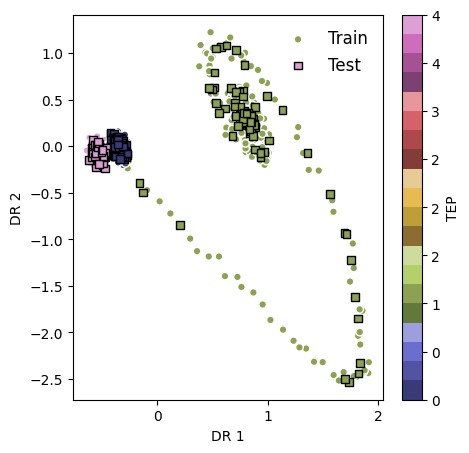

(<Figure size 500x500 with 2 Axes>, <Axes: xlabel='DR 1', ylabel='DR 2'>)

In [7]:
def plot_dr_projection(X_train_reduced, y_train, X_test_reduced=None, y_test=None,
                save_path=None, figsize=(5, 5), cmap='tab20b', s=30,
                xlabel='DR 1', ylabel='DR 2', colorbar_label='TEP'):
    """
    Plot DR-reduced training (and optional test) data.
    Parameters:
      - X_train_reduced: array-like, shape (n_samples_train, 2)
      - y_train: array-like, labels for train points
      - X_test_reduced: array-like or None, shape (n_samples_test, 2)
      - y_test: array-like or None, labels for test points
      - save_path: str or None, path to save the figure
      - figsize, cmap, s: plotting options
      - xlabel, ylabel, colorbar_label: axis/legend labels
    Returns:
      - fig, ax
    """
    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(X_train_reduced[:, 0], X_train_reduced[:, 1],
                    c=y_train, edgecolors='w', cmap=cmap, s=s)
    if X_test_reduced is not None and y_test is not None:
        ax.scatter(X_test_reduced[:, 0], X_test_reduced[:, 1],
                   marker='s', c=y_test, edgecolors='k', cmap=cmap, s=s, alpha=1)

    cbar = plt.colorbar(sc, ax=ax, label=colorbar_label)
    cbar.formatter = ticker.FormatStrFormatter('%.0f')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(['Train', 'Test'], loc='best', fontsize=12, frameon=False)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    plt.rcParams['font.size'] = 15
    plt.rcParams['axes.linewidth'] = 1

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Visualize the data
plot_dr_projection(X_train_reduced, y_train, X_test_reduced, y_test, save_path='figures/example-3-1-pca.png')

## tSNE

In [8]:
def tsne_reduce(X, n_components=2):
    """
    Reduce the dimensionality of the data using PCA.
    :param X: The data to be reduced.
    :param n_components: The number of components to reduce to.
    :return: The fitted TSNE model and the reduced data.
    """
    tsne_model = TSNE(n_components=n_components)
    X_reduced = tsne_model.fit_transform(X)
    return tsne_model, X_reduced

tsne_model, X_train_reduced = tsne_reduce(X_train_scaled, n_components=2)

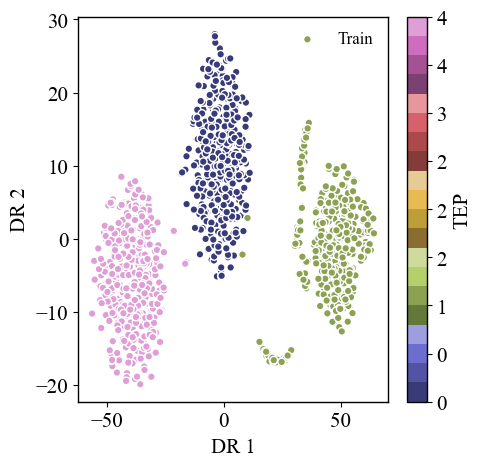

(<Figure size 500x500 with 2 Axes>, <Axes: xlabel='DR 1', ylabel='DR 2'>)

In [9]:
# Visualize the data
plot_dr_projection(X_train_reduced, y_train, X_test_reduced = None, y_test = None,
                   save_path='figures/example-3-1-tsne.png')

## PaCMAP

In [10]:
def pacmap_reduce(X, n_components=2):
    """
    Reduce the dimensionality of the data using pacmap.
    :param X: The data to be reduced.
    :param n_components: The number of components to reduce to.
    :return: The reduced data.
    """
    pacmap_model = pacmap.PaCMAP(n_components=n_components, n_neighbors=100, FP_ratio=10, save_tree=True)
    X_reduced = pacmap_model.fit_transform(X, init = 'pca')

    return pacmap_model, X_reduced

pacmap_model, X_train_reduced = pacmap_reduce(X_train_scaled, n_components=2)
X_test_reduced = pacmap_model.transform(X_test_scaled, init = 'pca')

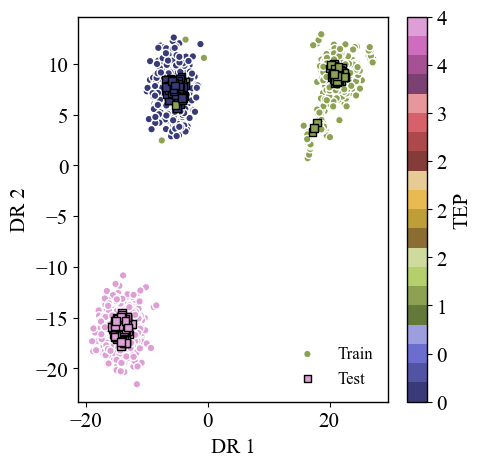

(<Figure size 500x500 with 2 Axes>, <Axes: xlabel='DR 1', ylabel='DR 2'>)

In [11]:
# Visualize the data
plot_dr_projection(X_train_reduced, y_train, X_test_reduced, y_test, save_path='figures/example-3-1-pacmap.png')